# EDA cho bộ dữ liệu

## Load thư viện

In [1]:
import os, sys
from IPython import display
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import pyplot
import pandas as pd
import seaborn as sns
import joblib

from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

import warnings

%matplotlib inline
# plt.rcParams["figure.figsize"] = (12, 6)
# plt.rcParams['figure.dpi'] = 100

warnings.filterwarnings("ignore")

## Load data

 Tập dữ liệu Titanic, gồm 891 hành khách với 12 đặc trưng (cột)

- PassengerId: Mã định danh duy nhất cho mỗi hành khách. Dùng để phân biệt từng dòng dữ liệu.

- Survived: Biến mục tiêu (target variable): 1 = sống sót, 0 = không sống sót


- Pclass: Hạng vé của hành khách: 1 = hạng nhất, 2 = hạng nhì, 3 = hạng ba. Biểu thị tầng lớp xã hội và điều kiện chỗ ngồi.


- Name: Tên đầy đủ của hành khách, có thể chứa cả danh xưng như Mr., Mrs., Miss., giúp xác định giới tính hoặc địa vị xã hội


- Sex: Giới tính của hành khách (male hoặc female). Thường là biến quan trọng trong dự đoán sống sót


- Age: Tuổi của hành khách. Dữ liệu định lượng có thể ảnh hưởng đến cơ hội sống sót (trẻ em, người lớn, người già)


- SibSp: Số anh/chị/em ruột hoặc vợ/chồng đi cùng trên tàu (Siblings/Spouses).


- Parch: Số cha/mẹ hoặc con đi cùng trên tàu (Parents/Children).


- Ticket: Số vé, có thể chứa ký tự hoặc số; đôi khi được dùng để nhóm các hành khách đi cùng nhau


- Fare: Giá vé mà hành khách đã trả. Phản ánh mức độ giàu có và có thể liên quan đến Pclass


- Cabin: Mã cabin cho biết khu vực ở trên tàu


- Embarked: Cảng lên tàu: C = Cherbourg, Q = Queenstown, S = Southampton. Có thể phản ánh nguồn gốc xã hội hoặc vị trí khoang.

In [2]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

In [3]:
print(f" Tổng số hàng và số cột của train_df: {train_df.shape}")
print(f"\n Tổng số hàng và cột của test_df: {test_df.shape}")

 Tổng số hàng và số cột của train_df: (891, 12)

 Tổng số hàng và cột của test_df: (418, 11)


In [4]:
# 10 hàng đầu tiên của tập train
print(train_df.head(10))

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6                            McCarthy, Mr. Timothy J    male  54

In [5]:
# 10 hàng đầu tiên của tập test
print(test_df.head(10))

   PassengerId  Pclass                                          Name     Sex  \
0          892       3                              Kelly, Mr. James    male   
1          893       3              Wilkes, Mrs. James (Ellen Needs)  female   
2          894       2                     Myles, Mr. Thomas Francis    male   
3          895       3                              Wirz, Mr. Albert    male   
4          896       3  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female   
5          897       3                    Svensson, Mr. Johan Cervin    male   
6          898       3                          Connolly, Miss. Kate  female   
7          899       2                  Caldwell, Mr. Albert Francis    male   
8          900       3     Abrahim, Mrs. Joseph (Sophie Halaut Easu)  female   
9          901       3                       Davies, Mr. John Samuel    male   

    Age  SibSp  Parch     Ticket     Fare Cabin Embarked  
0  34.5      0      0     330911   7.8292   NaN        Q  
1

In [6]:
# 10 hàng cuối của tập train
print(train_df.tail(10))

     PassengerId  Survived  Pclass                                      Name  \
881          882         0       3                        Markun, Mr. Johann   
882          883         0       3              Dahlberg, Miss. Gerda Ulrika   
883          884         0       2             Banfield, Mr. Frederick James   
884          885         0       3                    Sutehall, Mr. Henry Jr   
885          886         0       3      Rice, Mrs. William (Margaret Norton)   
886          887         0       2                     Montvila, Rev. Juozas   
887          888         1       1              Graham, Miss. Margaret Edith   
888          889         0       3  Johnston, Miss. Catherine Helen "Carrie"   
889          890         1       1                     Behr, Mr. Karl Howell   
890          891         0       3                       Dooley, Mr. Patrick   

        Sex   Age  SibSp  Parch            Ticket     Fare Cabin Embarked  
881    male  33.0      0      0            

In [7]:
# 10 hàng cuối của tập test
print(test_df.tail(10))

     PassengerId  Pclass                                             Name  \
408         1300       3                  Riordan, Miss. Johanna Hannah""   
409         1301       3                        Peacock, Miss. Treasteall   
410         1302       3                           Naughton, Miss. Hannah   
411         1303       1  Minahan, Mrs. William Edward (Lillian E Thorpe)   
412         1304       3                   Henriksson, Miss. Jenny Lovisa   
413         1305       3                               Spector, Mr. Woolf   
414         1306       1                     Oliva y Ocana, Dona. Fermina   
415         1307       3                     Saether, Mr. Simon Sivertsen   
416         1308       3                              Ware, Mr. Frederick   
417         1309       3                         Peter, Master. Michael J   

        Sex   Age  SibSp  Parch              Ticket      Fare Cabin Embarked  
408  female   NaN      0      0              334915    7.7208   NaN      

In [8]:
# Thông tin cơ bản của tập train
print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [9]:
# Thống kê mô tả các biến số
print(train_df.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [10]:
# Thống kê mô tả cho các biến phân loại
print("THỐNG KÊ MÔ TẢ CÁC BIẾN PHÂN LOẠI")
print(train_df.describe(include=['object']))

# Kiểm tra giá trị duy nhất của mỗi cột
print("SỐ LƯỢNG GIÁ TRỊ DUY NHẤT CỦA MỖI CỘT")
for col in train_df.columns:
    print(f"{col:15} : {train_df[col].nunique():5} giá trị duy nhất")

THỐNG KÊ MÔ TẢ CÁC BIẾN PHÂN LOẠI
                           Name   Sex  Ticket    Cabin Embarked
count                       891   891     891      204      889
unique                      891     2     681      147        3
top     Braund, Mr. Owen Harris  male  347082  B96 B98        S
freq                          1   577       7        4      644
SỐ LƯỢNG GIÁ TRỊ DUY NHẤT CỦA MỖI CỘT
PassengerId     :   891 giá trị duy nhất
Survived        :     2 giá trị duy nhất
Pclass          :     3 giá trị duy nhất
Name            :   891 giá trị duy nhất
Sex             :     2 giá trị duy nhất
Age             :    88 giá trị duy nhất
SibSp           :     7 giá trị duy nhất
Parch           :     7 giá trị duy nhất
Ticket          :   681 giá trị duy nhất
Fare            :   248 giá trị duy nhất
Cabin           :   147 giá trị duy nhất
Embarked        :     3 giá trị duy nhất


In [13]:
# Tần xuất xuất hiện của các biến số.
print("THỐNG KÊ TẦN SUẤT CÁC BIẾN SỐ")
for col in ['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch','Embarked']:
    print(f"\nGiá trị duy nhất trong {col}: {train_df[col].unique()}")
    print(train_df[col].value_counts())

THỐNG KÊ TẦN SUẤT CÁC BIẾN SỐ

Giá trị duy nhất trong Survived: [0 1]
Survived
0    549
1    342
Name: count, dtype: int64

Giá trị duy nhất trong Pclass: [3 1 2]
Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Giá trị duy nhất trong Sex: ['male' 'female']
Sex
male      577
female    314
Name: count, dtype: int64

Giá trị duy nhất trong SibSp: [1 0 3 4 2 5 8]
SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

Giá trị duy nhất trong Parch: [0 1 2 5 3 4 6]
Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

Giá trị duy nhất trong Embarked: ['S' 'C' 'Q' nan]
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


## kiểm tra dữ liệu

In [14]:
# Kiểm tra các cột khác nhau trong tập dữ liệu train và test
print("Cột khác nhau giữa train và test:", set(train_df.columns) - set(test_df.columns))
print("So sánh kiểu dữ liệu giữa train/test:")
print(pd.concat([train_df.dtypes, test_df.dtypes], axis=1, keys=['Train', 'Test']))

Cột khác nhau giữa train và test: {'Survived'}
So sánh kiểu dữ liệu giữa train/test:
               Train     Test
PassengerId    int64    int64
Survived       int64      NaN
Pclass         int64    int64
Name          object   object
Sex           object   object
Age          float64  float64
SibSp          int64    int64
Parch          int64    int64
Ticket        object   object
Fare         float64  float64
Cabin         object   object
Embarked      object   object


In [15]:
# Kiểm tra tồn tại của giá trị Null
print("="*5, "Kiểm tra NULL", "="*5)
display.display(train_df.isnull().sum())
has_null = train_df.isnull().sum().any()
print(f'--> Có giá trị Null: {has_null}')
if has_null:
    display.display(train_df[train_df.isnull().any(axis=1)])

===== Kiểm tra NULL =====


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

--> Có giá trị Null: True


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.0500,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


In [16]:
# Kiểm tra tồn tại của giá trị NaN
print("="*5, "Kiểm tra NaN", "="*5)
display.display(train_df.isna().sum())
has_nan  = train_df.isna().sum().any()
print(f'+ Có giá trị Nan: {has_nan}')
if has_nan:
    display.display(train_df[train_df.isna().any(axis=1)])

===== Kiểm tra NaN =====


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

+ Có giá trị Nan: True


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.0500,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


In [17]:
# Kiểm tra trùng lặp
print("="*5, "Kiểm tra trùng lặp:", "="*5)
n_duplicated = train_df.duplicated(keep = False).sum()
print(f'+ Số dòng trùng: {n_duplicated}')
display.display(train_df[train_df.duplicated(keep = False)])
if n_duplicated>0:
    print("+ Số dòng loại bỏ: %d"%(len(df_dataset[df_dataset.duplicated(keep = "first")])))
    display.display(train_df[train_df.duplicated(keep = "first")])

===== Kiểm tra trùng lặp: =====
+ Số dòng trùng: 0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


<Axes: ylabel='Fare'>

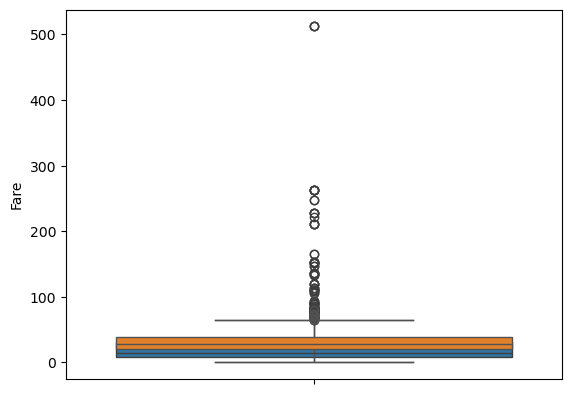

In [18]:
# Kiểm tra giá trị outlier
sns.boxplot(data=train_df, y='Fare')
sns.boxplot(data=train_df, y='Age')

In [19]:
# Hàm kiểm tra missing data
def missing_data_analysis(df, dataset_name='Dataset'):
    """
    Phân tích dữ liệu thiếu trong dataframe
    """
    # Tính số lượng và tỷ lệ missing
    missing_count = df.isnull().sum()
    missing_percent = (missing_count / len(df)) * 100
    
    # Tạo dataframe kết quả
    missing_df = pd.DataFrame({
        'Column': missing_count.index,
        'Missing_Count': missing_count.values,
        'Missing_Percent': missing_percent.values
    })
    # Chỉ lấy các cột có missing data
    missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values(
        'Missing_Percent', ascending=False
    ).reset_index(drop=True)

    print(f"\n{dataset_name}:")
    if len(missing_df) == 0:
        print("Không có dữ liệu thiếu!")
    else:
        print(missing_df.to_string(index=False))
    
    return missing_df

Dữ liệu bị thiếu:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


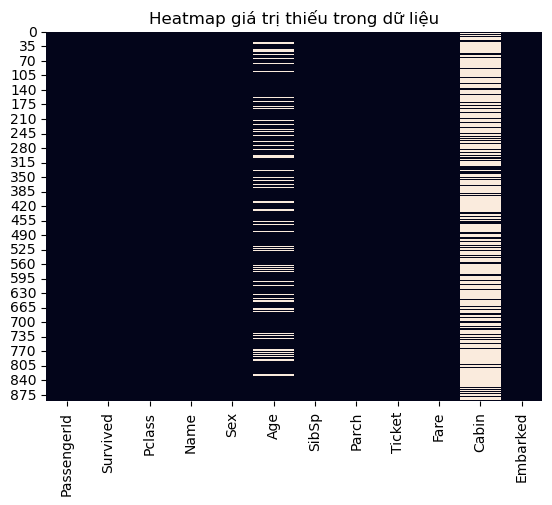

In [22]:
# Print missing data counts
missing_train = train_df.isnull().sum()
print("Dữ liệu bị thiếu:\n", missing_train)

# Trực quan các giá trị bị thiếu
sns.heatmap(train_df.isnull(), cbar=False)
plt.title("Heatmap giá trị thiếu trong dữ liệu")
plt.show()

Dữ liệu bị thiếu:
 PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


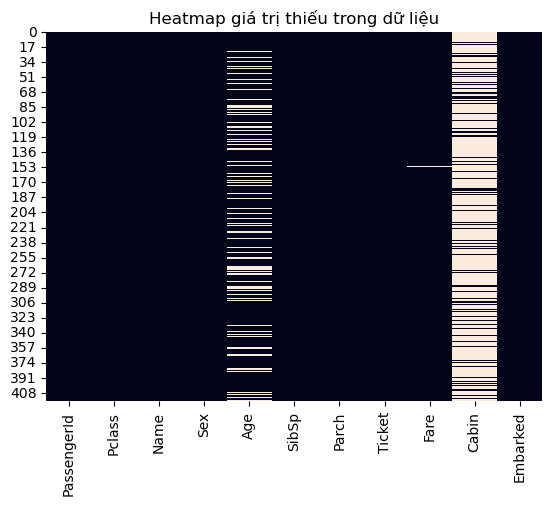

In [21]:
# Print missing data counts
missing_train = test_df.isnull().sum()
print("Dữ liệu bị thiếu:\n", missing_train)

# Trực quan các giá trị bị thiếu
sns.heatmap(test_df.isnull(), cbar=False)
plt.title("Heatmap giá trị thiếu trong dữ liệu")
plt.show()

In [ ]:
# histogram
train_df.hist(figsize=(15, 10), bins=20, edgecolor='black')
plt.suptitle('Phân bố các biến số liên tục của tập train')
plt.show()

In [ ]:
# density
train_df.plot(kind='density', subplots=True, layout=(3,3), sharex=False)
pyplot.show()

In [ ]:
# box and whisker plots
train_df.plot(kind='box', subplots=True, layout=(3,3), sharex=False, sharey=False,
figsize=(12,6))
train_df.plot(kind="box", figsize=(10,5));
pyplot.show()

## Phân tích mối quan hệ của biến Survived với các biến còn lại

In [ ]:
# Phân tích Phân bố của Biến mục tiêu Survived
print(train_df['Survived'].value_counts(normalize=True))
sns.countplot(x='Survived', data=train_df)
plt.title('Phân bố của Biến mục tiêu (0: Không Sống sót, 1: Sống sót)')
plt.show()

In [ ]:
# Mối quan hệ giữa Pclass và Survived
print(train_df[['Pclass', 'Survived']].groupby(['Pclass']).mean().sort_values(by='Survived', ascending=False))
sns.barplot(x='Pclass', y='Survived', data=train_df)
plt.title('Tỷ lệ Sống sót theo Hạng ghế (Pclass)')
plt.show()

In [ ]:
# Mối quan hệ giữa Sex và Survived
print(train_df[['Sex', 'Survived']].groupby(['Sex']).mean().sort_values(by='Survived', ascending=False))
sns.barplot(x='Sex', y='Survived', data=train_df)
plt.title('Tỷ lệ Sống sót theo giới tính (Sex)')
plt.show()

In [ ]:
# Mối quan hệ giữa Embarked và Survived
print(train_df[['Embarked', 'Survived']].groupby(['Embarked']).mean().sort_values(by='Survived', ascending=False))
sns.barplot(x='Embarked', y='Survived', data=train_df)
plt.title('Tỷ lệ Sống sót theo Cảng lên tàu (Embarked)')
plt.show()

In [ ]:
# Mối quan hệ giữa Age và Survived
print(train_df[['Age', 'Survived']].groupby(['Age']).mean().sort_values(by='Survived', ascending=False))
sns.boxplot(data=train_df, x='Survived', y='Age')
plt.title('Tỷ lệ Sống sót theo độ tuổi (Age)')
plt.show()

In [ ]:
# Histogram cho Fare (Kiểm tra độ lệch và Outlier)
plt.figure(figsize=(10, 4))
sns.histplot(train_df['Fare'], kde=True)
plt.title('Phân bố của Fare')
plt.show()

In [ ]:
# correlation matrix
sns.heatmap(train_df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Ma trận Tương quan')
plt.show()